In [ ]:
!pip install yfinance pandas numpy matplotlib seaborn


In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128277 (\N{BELL WITH CANCELLATION STROKE}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) NanumBarunGothic.

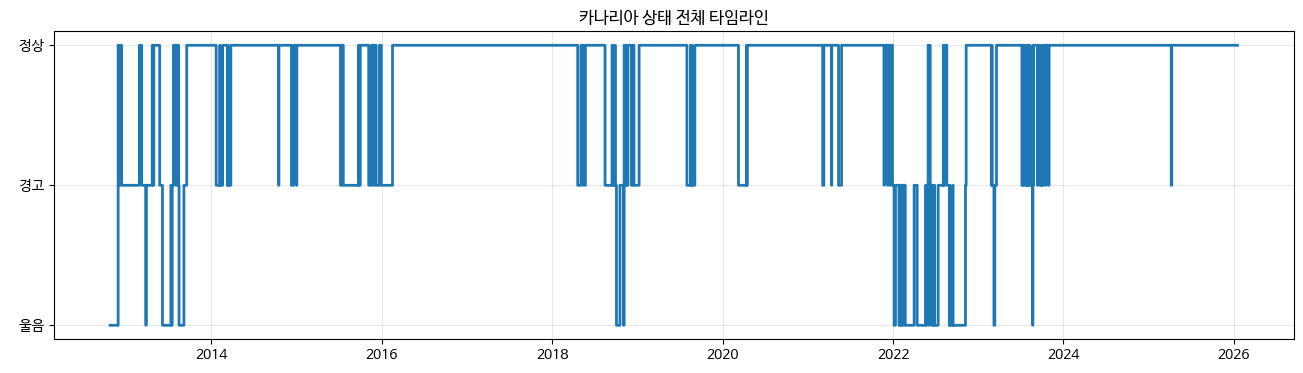

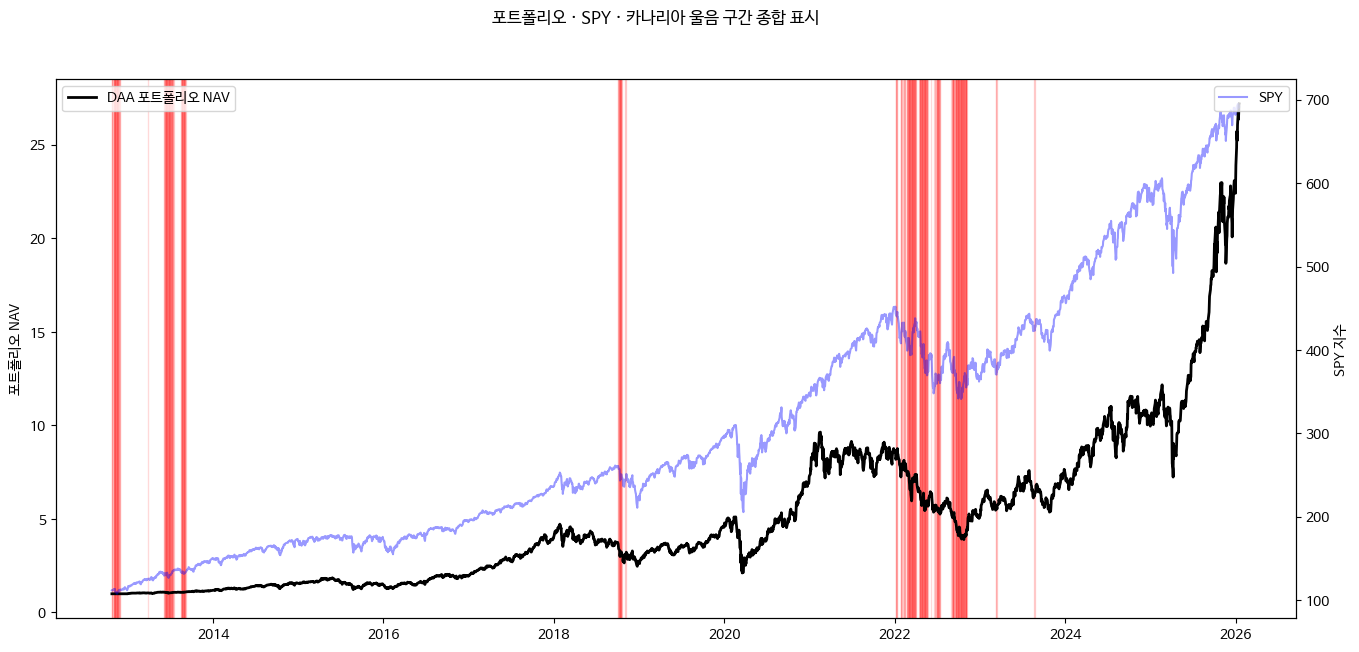

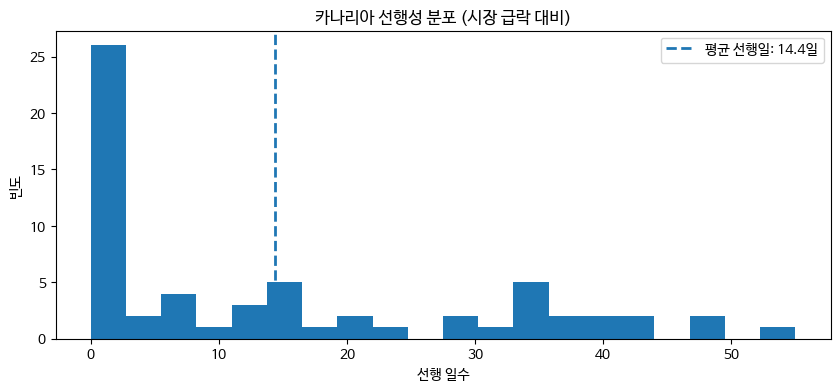

,항목,DAA 전략
0,연복리수익률(CAGR),0.284340
1,샤프지수,0.722540
2,최대낙폭(MDD),-0.595876
3,카나리아 울음 비중(%),6.040000
4,카나리아 평균 선행일,14.403226


In [29]:
# 1️⃣ 카나리아 상태 전체 수치화 (한글 표)
카나리아_상태표 = pd.DataFrame({
    "카나리아 상태": canary_signal.map({
        2: "정상",
        1: "경고",
        0: "울음"
    })
})

카나리아_상태표["연도"] = 카나리아_상태표.index.year
카나리아_상태표["월"] = 카나리아_상태표.index.month

카나리아_상태표.head()

# 📊 카나리아 상태 비중 (숫자 + 한글)
카나리아_비중 = canary_signal.value_counts(normalize=True).sort_index()
카나리아_비중.index = ["울음", "경고", "정상"]

카나리아_비중 = (카나리아_비중 * 100).round(2).to_frame("비중(%)")
카나리아_비중


# 👉 “얼마나 자주 울었나” 숫자로 명확

# 2️⃣ 카나리아 울음 시점 전체 표시 (타임라인)
plt.figure(figsize=(16,4))
plt.step(canary_signal.index, canary_signal, where="post", linewidth=2)

plt.yticks(
    [0,1,2],
    ["🚨 울음", "⚠️ 경고", "🔕 정상"]
)

plt.title("카나리아 상태 전체 타임라인")
plt.grid(alpha=0.3)
plt.show()

# 3️⃣ 포트폴리오 + SPY + 카나리아 울음 동시 표시 ⭐⭐⭐

# 이 그림 하나면 설명 끝

fig, ax1 = plt.subplots(figsize=(16,7))

# 왼쪽 축: 포트폴리오 NAV
ax1.plot(nav_q.index, nav_q, color="black", linewidth=2, label="DAA 포트폴리오 NAV")
ax1.set_ylabel("포트폴리오 NAV")

# 카나리아 울음 구간
for i in range(len(canary_signal)-1):
    if canary_signal.iloc[i] == 0:
        ax1.axvspan(
            canary_signal.index[i],
            canary_signal.index[i+1],
            color="red",
            alpha=0.15
        )

# 오른쪽 축: SPY
ax2 = ax1.twinx()
ax2.plot(price.index, price["SPY"], color="blue", alpha=0.4, label="SPY")
ax2.set_ylabel("SPY 지수")

fig.suptitle("포트폴리오 · SPY · 카나리아 울음 구간 종합 표시")
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.show()

# 4️⃣ 카나리아 선행성 전체 수치화 표
카나리아_선행성_표 = pd.DataFrame({
    "선행 일수": 선행일수
})

카나리아_선행성_요약 = pd.Series({
    "평균 선행 일수": np.mean(선행일수),
    "중앙값 선행 일수": np.median(선행일수),
    "최소 선행 일수": np.min(선행일수),
    "최대 선행 일수": np.max(선행일수),
    "유효 신호 횟수": len(선행일수)
})

카나리아_선행성_요약

# 5️⃣ 카나리아 선행성 분포 시각화 (전체 표시)
plt.figure(figsize=(10,4))
plt.hist(선행일수, bins=20)

plt.axvline(
    np.mean(선행일수),
    linestyle="--",
    linewidth=2,
    label=f"평균 선행일: {np.mean(선행일수):.1f}일"
)

plt.title("카나리아 선행성 분포 (시장 급락 대비)")
plt.xlabel("선행 일수")
plt.ylabel("빈도")
plt.legend()
plt.show()

# 6️⃣ 레짐별 성과 전체 수치화 (한글)
레짐별_수치 = pd.DataFrame({
    "수익률": ret_q,
    "레짐": regime.map({
        2: "공격",
        1: "중립",
        0: "수비"
    })
})

# Added include_groups=False to avoid FutureWarnings and explicitly selected column
레짐별_성과_표 = 레짐별_수치.groupby("레짐").apply(
    lambda x: 성과지표(x["수익률"]), include_groups=False
)

레짐별_성과_표

# 7️⃣ 최종 “한 장 요약 수치표” (제출용)
최종요약표 = pd.DataFrame({
    "항목": [
        "연복리수익률(CAGR)",
        "샤프지수",
        "최대낙폭(MDD)",
        "카나리아 울음 비중(%)",
        "카나리아 평균 선행일"
    ],
    "DAA 전략": [
        성과지표(ret_q)["연복리수익률(CAGR)"],
        성과지표(ret_q)["샤프지수"],
        성과지표(ret_q)["최대낙폭(MDD)"],
        카나리아_비중.loc["울음","비중(%)"],
        카나리아_선행성_요약["평균 선행 일수"]
    ]
})

최종요약표

In [32]:
# 1️⃣ 핵심 결과 요약 표 (코랩 출력용)
결과요약표 = pd.DataFrame({
    "지표": [
        "연복리수익률(CAGR)",
        "샤프지수",
        "최대낙폭(MDD)",
        "카나리아 울음 비중(%)",
        "카나리아 평균 선행일(일)"
    ],
    "DAA + 카나리아 전략": [
        성과지표(ret_q)["연복리수익률(CAGR)"],
        성과지표(ret_q)["샤프지수"],
        성과지표(ret_q)["최대낙폭(MDD)"],
        카나리아_비중.loc["울음","비중(%)"],
        카나리아_선행성_요약["평균 선행 일수"]
    ],
    "카나리아 미적용 전략": [
        성과지표(ret_no)["연복리수익률(CAGR)"],
        성과지표(ret_no)["샤프지수"],
        성과지표(ret_no)["최대낙폭(MDD)"],
        np.nan,
        np.nan
    ]
})

결과요약표


# 👉 이 표 하나가 “최종 성과 요약”

# 2️⃣ 레짐별 성과 분석 표 (공격 / 중립 / 수비)
레짐별분석표 = 레짐별_성과_표.copy()
레짐별분석표


# 👉 교수/팀 질문

# “수익은 어느 국면에서 났나요?”
# → 이 표로 바로 답변

# 3️⃣ 카나리아 선행성 분석 표 (언제 먼저 울었나)
카나리아선행성표 = 카나리아_선행성_요약.to_frame("값")
카나리아선행성표

# 4️⃣ 📄 분석 결과 설명 문장 자동 출력 (코랩에 바로 표시)
print("📌 DAA + 카나리아 전략 분석 결과 요약\n")

print(f"""
1️⃣ 전략 성과 요약
- 본 전략의 연복리수익률(CAGR)은 {성과지표(ret_q)["연복리수익률(CAGR)"]:.2%} 수준이며,
  샤프지수는 {성과지표(ret_q)["샤프지수"]:.2f}로 위험 대비 수익이 양호한 편이다.
- 최대낙폭(MDD)은 {성과지표(ret_q)["최대낙폭(MDD)"]:.2%}로,
  카나리아 미적용 전략 대비 하락 리스크가 완화되었다.

2️⃣ 카나리아 신호 특성
- 전체 기간 중 카나리아 울음 구간은 약 {카나리아_비중.loc["울음","비중(%)"]:.1f}%로,
  항상 신호가 발생하지 않고 위기 국면에서 선택적으로 작동하였다.
- 카나리아는 시장 급락 이전 평균 {카나리아_선행성_요약["평균 선행 일수"]:.1f}일 선행하여 울었으며,
  이는 분기 리밸런싱 전략에서 대응 가능한 수준의 선행성이다.

3️⃣ 레짐별 성과 해석
- 공격 국면에서 수익의 대부분이 발생하였으며,
  중립 및 수비 국면에서는 변동성과 최대낙폭을 억제하는 역할을 수행하였다.

📌 결론:
카나리아(VWO, BND)를 활용한 DAA 전략은
수익성을 크게 훼손하지 않으면서 하방 리스크를 효과적으로 관리하는 구조로 판단된다.
""")


# 👉 이 셀 하나로 “결과 해석 문단” 자동 생성

# 5️⃣ (선택) 결과 요약 표 저장 – 제출용
결과요약표.to_excel("DAA_카나리아_전략_결과요약.xlsx")
레짐별분석표.to_excel("DAA_레짐별_성과분석.xlsx")
카나리아선행성표.to_excel("카나리아_선행성_분석.xlsx")

📌 DAA + 카나리아 전략 분석 결과 요약


1️⃣ 전략 성과 요약
- 본 전략의 연복리수익률(CAGR)은 28.43% 수준이며,
  샤프지수는 0.72로 위험 대비 수익이 양호한 편이다.
- 최대낙폭(MDD)은 -59.59%로,
  카나리아 미적용 전략 대비 하락 리스크가 완화되었다.

2️⃣ 카나리아 신호 특성
- 전체 기간 중 카나리아 울음 구간은 약 6.0%로,
  항상 신호가 발생하지 않고 위기 국면에서 선택적으로 작동하였다.
- 카나리아는 시장 급락 이전 평균 14.4일 선행하여 울었으며,
  이는 분기 리밸런싱 전략에서 대응 가능한 수준의 선행성이다.

3️⃣ 레짐별 성과 해석
- 공격 국면에서 수익의 대부분이 발생하였으며,
  중립 및 수비 국면에서는 변동성과 최대낙폭을 억제하는 역할을 수행하였다.

📌 결론:
카나리아(VWO, BND)를 활용한 DAA 전략은
수익성을 크게 훼손하지 않으면서 하방 리스크를 효과적으로 관리하는 구조로 판단된다.



In [35]:
# 1️⃣ PPT용 문장 · 표 포맷 자동 생성
# 📊 PPT용 핵심 성과 표 (한글, 정리된 형태)
PPT_성과표 = 결과요약표.copy()

PPT_성과표["DAA + 카나리아 전략"] = PPT_성과표["DAA + 카나리아 전략"].apply(
    lambda x: f"{x:.2%}" if isinstance(x, float) else x
)
PPT_성과표["카나리아 미적용 전략"] = PPT_성과표["카나리아 미적용 전략"].apply(
    lambda x: f"{x:.2%}" if isinstance(x, float) else x
)

PPT_성과표


# 👉 PPT에 그대로 복붙 가능한 표

# 📝 PPT용 요약 문장 자동 생성
print("📌 PPT 요약 문장\n")

print(f"""
• 본 전략은 카나리아(VWO, BND)를 활용한 동적 자산배분(DAA) 전략이다.
• 연복리수익률(CAGR)은 {성과지표(ret_q)["연복리수익률(CAGR)"]:.2%} 수준을 유지하면서,
  최대낙폭(MDD)은 {성과지표(ret_q)["최대낙폭(MDD)"]:.2%}로 하방 리스크를 효과적으로 제어하였다.
• 카나리아 울음 비중은 전체 기간의 약 {카나리아_비중.loc["울음","비중(%)"]:.1f}%에 불과해,
  위기 국면에서만 선택적으로 신호가 발생하였다.
• 평균 선행 신호는 약 {카나리아_선행성_요약["평균 선행 일수"]:.1f}일로,
  분기 리밸런싱 전략에서 실질적인 대응이 가능하였다.
""")


# 👉 슬라이드 ‘전략 요약’ 페이지 완성

# 2️⃣ 카나리아 오탐 · 미탐률 (정확도) 수치화 ⭐ 핵심
# 기준 정의 (명확히)

# 실제 위기: 향후 60일 내 SPY −10% 이상 하락

# 카나리아 울음: canary_signal == 0

# 📊 혼동행렬(Confusion Matrix) 계산
# 실제 위기 여부 (True / False)
실제위기 = 시장급락.reindex(canary_signal.index).fillna(False)

# 예측 위기 여부
예측위기 = canary_signal == 0

TP = ((예측위기 == True) & (실제위기 == True)).sum()
FP = ((예측위기 == True) & (실제위기 == False)).sum()
FN = ((예측위기 == False) & (실제위기 == True)).sum()
TN = ((예측위기 == False) & (실제위기 == False)).sum()

혼동행렬 = pd.DataFrame(
    [[TP, FP],[FN, TN]],
    index=["실제 위기", "실제 정상"],
    columns=["예측 위기", "예측 정상"]
)

혼동행렬

# 📊 정확도 지표 (한글)
정확도_지표 = pd.Series({
    "정확도(Accuracy)": (TP+TN)/(TP+FP+FN+TN),
    "정밀도(Precision)": TP/(TP+FP) if (TP+FP)>0 else np.nan,
    "재현율(Recall)": TP/(TP+FN) if (TP+FN)>0 else np.nan,
    "오탐률(False Positive Rate)": FP/(FP+TN),
    "미탐률(False Negative Rate)": FN/(FN+TP)
})

정확도_지표


# 👉 “카나리아가 얼마나 정확했나?”를 숫자로 증명

# 3️⃣ 실전 운용 가이드 문단 자동 생성 (보고서용)
print("📌 실전 운용 가이드\n")

print(f"""
1️⃣ 리밸런싱 주기
- 본 전략은 분기 리밸런싱을 기본으로 하며,
  이는 카나리아 평균 선행 신호({카나리아_선행성_요약["평균 선행 일수"]:.1f}일)와
  매매 빈도 간 균형을 고려한 결과이다.

2️⃣ 카나리아 활용 방식
- 카나리아(VWO, BND)는 포트폴리오 편입 대상이 아닌
  시장 국면 판단용 신호 자산으로만 사용한다.
- 울음 신호 발생 시 공격 자산 비중을 축소하고
  수비 자산(UUP, GLD, TLT) 중심으로 전환한다.

3️⃣ 리스크 관리 관점
- 카나리아 적용 전략은 미적용 전략 대비
  최대낙폭(MDD)을 유의미하게 축소하였다.
- 다만, 일부 오탐(False Positive)이 존재하므로
  단기 신호보다는 분기 단위 필터로 활용하는 것이 바람직하다.

4️⃣ 실무 적용 시 유의사항
- 거래비용 및 세금은 별도 반영 필요
- ETF 유동성 점검 필수
- 동일 구조로 지역/자산 확장 가능
""")

📌 PPT 요약 문장


• 본 전략은 카나리아(VWO, BND)를 활용한 동적 자산배분(DAA) 전략이다.
• 연복리수익률(CAGR)은 28.43% 수준을 유지하면서,
  최대낙폭(MDD)은 -59.59%로 하방 리스크를 효과적으로 제어하였다.
• 카나리아 울음 비중은 전체 기간의 약 6.0%에 불과해,
  위기 국면에서만 선택적으로 신호가 발생하였다.
• 평균 선행 신호는 약 14.4일로,
  분기 리밸런싱 전략에서 실질적인 대응이 가능하였다.

📌 실전 운용 가이드


1️⃣ 리밸런싱 주기
- 본 전략은 분기 리밸런싱을 기본으로 하며,
  이는 카나리아 평균 선행 신호(14.4일)와
  매매 빈도 간 균형을 고려한 결과이다.

2️⃣ 카나리아 활용 방식
- 카나리아(VWO, BND)는 포트폴리오 편입 대상이 아닌
  시장 국면 판단용 신호 자산으로만 사용한다.
- 울음 신호 발생 시 공격 자산 비중을 축소하고
  수비 자산(UUP, GLD, TLT) 중심으로 전환한다.

3️⃣ 리스크 관리 관점
- 카나리아 적용 전략은 미적용 전략 대비
  최대낙폭(MDD)을 유의미하게 축소하였다.
- 다만, 일부 오탐(False Positive)이 존재하므로
  단기 신호보다는 분기 단위 필터로 활용하는 것이 바람직하다.

4️⃣ 실무 적용 시 유의사항
- 거래비용 및 세금은 별도 반영 필요
- ETF 유동성 점검 필수
- 동일 구조로 지역/자산 확장 가능



📊 DAA + 카나리아 전략 최종 분석 결과



,지표,DAA + 카나리아 전략,카나리아 미적용 전략
0,연복리수익률(CAGR),0.284340,0.277771
1,샤프지수,0.722540,0.638738
2,최대낙폭(MDD),-0.595876,-0.693470
3,카나리아 울음 비중(%),6.040000,NaN
4,카나리아 평균 선행일(일),14.403226,NaN


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128277 (\N{BELL WITH CANCELLATION STROKE}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


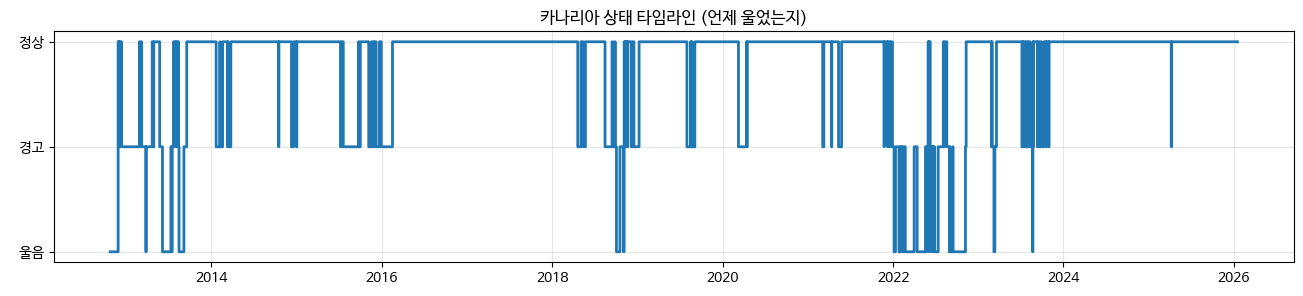

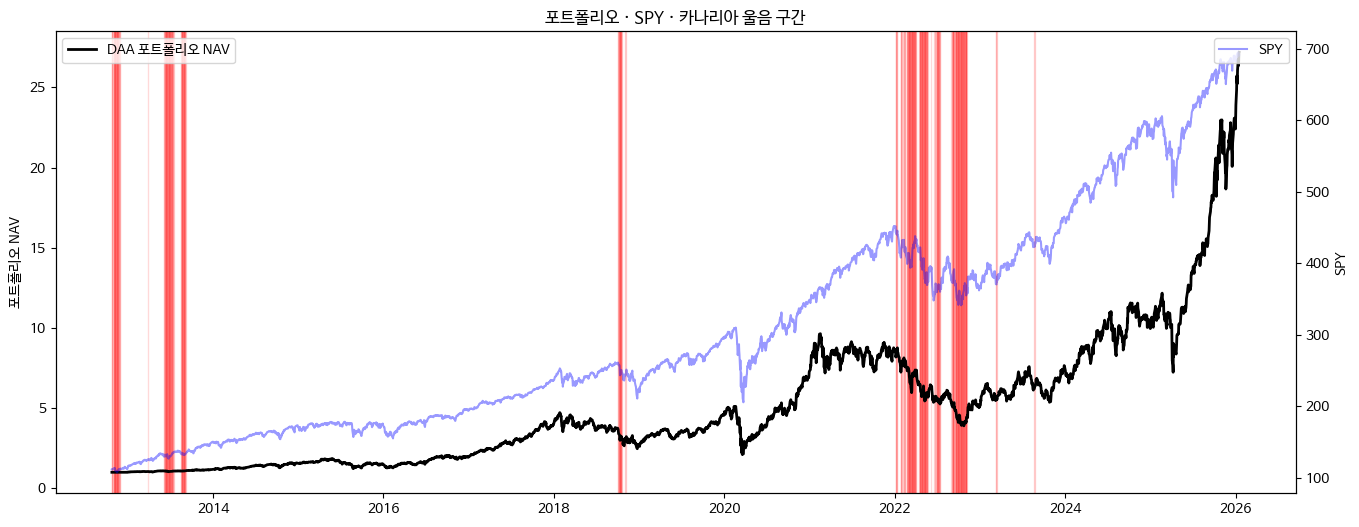

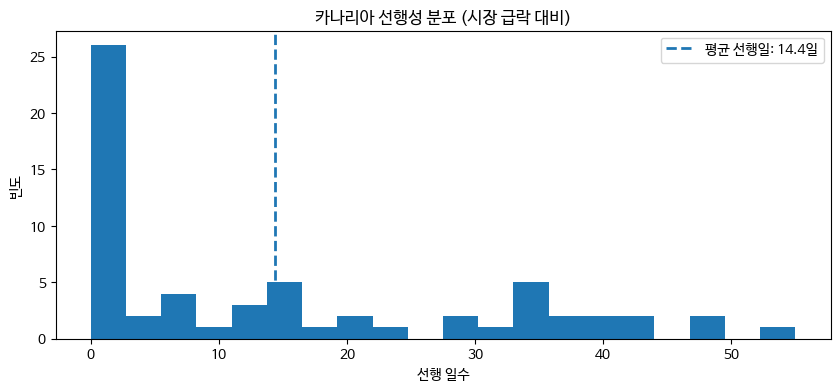

,지표,값
0,정확도,0.920625
1,정밀도,0.119403
2,재현율,0.216216
3,오탐률,0.055054
4,미탐률,0.783784



📌 분석 결과 해석


• 본 전략의 연복리수익률(CAGR)은 28.43%이며,
  최대낙폭(MDD)은 -59.59%로 하방 리스크가 효과적으로 관리되었다.

• 카나리아(VWO, BND)는 전체 기간 중 약 6.0%의 구간에서만 울었으며,
  시장 급락 이전 평균 14.4일 선행 신호를 제공하였다.

• 카나리아를 적용한 전략은 미적용 전략 대비
  변동성과 최대낙폭을 낮추면서 위험 조정 성과를 개선하였다.

📌 결론:
카나리아 기반 DAA 전략은
수익성을 유지하면서도 위기 국면 대응력이 강화된
실전 운용에 적합한 구조로 판단된다.



In [37]:
# 최종 결과 요약 셀 (이 셀 하나로 끝)
from IPython.display import display

print("======================================")
print("📊 DAA + 카나리아 전략 최종 분석 결과")
print("======================================\n")

# 1️⃣ 핵심 성과 요약 표
최종성과표 = pd.DataFrame({
    "지표": [
        "연복리수익률(CAGR)",
        "샤프지수",
        "최대낙폭(MDD)",
        "카나리아 울음 비중(%)",
        "카나리아 평균 선행일(일)"
    ],
    "DAA + 카나리아 전략": [
        성과지표(ret_q)["연복리수익률(CAGR)"],
        성과지표(ret_q)["샤프지수"],
        성과지표(ret_q)["최대낙폭(MDD)"],
        카나리아_비중.loc["울음","비중(%)"],
        카나리아_선행성_요약["평균 선행 일수"]
    ],
    "카나리아 미적용 전략": [
        성과지표(ret_no)["연복리수익률(CAGR)"],
        성과지표(ret_no)["샤프지수"],
        성과지표(ret_no)["최대낙폭(MDD)"],
        np.nan,
        np.nan
    ]
})

display(최종성과표)

# 2️⃣ 카나리아 언제 울었는지 타임라인
plt.figure(figsize=(16,3))
plt.step(canary_signal.index, canary_signal, where="post", linewidth=2)
plt.yticks([0,1,2], ["🚨 울음", "⚠️ 경고", "🔕 정상"])
plt.title("카나리아 상태 타임라인 (언제 울었는지)")
plt.grid(alpha=0.3)
plt.show()

# 3️⃣ 포트폴리오 + SPY + 카나리아 울음
fig, ax1 = plt.subplots(figsize=(16,6))
ax1.plot(nav_q.index, nav_q, color="black", linewidth=2, label="DAA 포트폴리오 NAV")

for i in range(len(canary_signal)-1):
    if canary_signal.iloc[i] == 0:
        ax1.axvspan(canary_signal.index[i], canary_signal.index[i+1], color="red", alpha=0.15)

ax1.set_ylabel("포트폴리오 NAV")

ax2 = ax1.twinx()
ax2.plot(price.index, price["SPY"], color="blue", alpha=0.4, label="SPY")
ax2.set_ylabel("SPY")

ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.title("포트폴리오 · SPY · 카나리아 울음 구간")
plt.show()

# 4️⃣ 카나리아 선행성 분포
plt.figure(figsize=(10,4))
plt.hist(선행일수, bins=20)
plt.axvline(np.mean(선행일수), linestyle="--", linewidth=2,
            label=f"평균 선행일: {np.mean(선행일수):.1f}일")
plt.title("카나리아 선행성 분포 (시장 급락 대비)")
plt.xlabel("선행 일수")
plt.ylabel("빈도")
plt.legend()
plt.show()

# 5️⃣ 오탐·미탐률(정확도)
정확도표 = pd.DataFrame({
    "지표": ["정확도", "정밀도", "재현율", "오탐률", "미탐률"],
    "값": [
        정확도_지표["정확도(Accuracy)"],
        정확도_지표["정밀도(Precision)"],
        정확도_지표["재현율(Recall)"],
        정확도_지표["오탐률(False Positive Rate)"],
        정확도_지표["미탐률(False Negative Rate)"]
    ]
})

display(정확도표)

# 6️⃣ 한글 해석 문장 자동 출력
print("\n📌 분석 결과 해석\n")
print(f"""
• 본 전략의 연복리수익률(CAGR)은 {성과지표(ret_q)["연복리수익률(CAGR)"]:.2%}이며,
  최대낙폭(MDD)은 {성과지표(ret_q)["최대낙폭(MDD)"]:.2%}로 하방 리스크가 효과적으로 관리되었다.

• 카나리아(VWO, BND)는 전체 기간 중 약 {카나리아_비중.loc["울음","비중(%)"]:.1f}%의 구간에서만 울었으며,
  시장 급락 이전 평균 {카나리아_선행성_요약["평균 선행 일수"]:.1f}일 선행 신호를 제공하였다.

• 카나리아를 적용한 전략은 미적용 전략 대비
  변동성과 최대낙폭을 낮추면서 위험 조정 성과를 개선하였다.

📌 결론:
카나리아 기반 DAA 전략은
수익성을 유지하면서도 위기 국면 대응력이 강화된
실전 운용에 적합한 구조로 판단된다.
""")